In [1]:
import pandas as pd
problem_df = pd.read_parquet('/kaggle/input/mooccubex-cleaned/problem_df_cleaned.parquet')
user_problem_df = pd.read_parquet('/kaggle/input/mooccubex-cleaned/user_problem.parquet')
users_course_labeling_df = pd.read_csv('/kaggle/input/mooccubex-cleaned/user_reduce_use_labeling.csv')
user_video_score_df = pd.read_parquet('/kaggle/input/d-liu-gn-nhn/user_video_scores.parquet')
exercise_have_problem_df= pd.read_parquet('/kaggle/input/mooccubex-cleaned/resource_exercise_course_have_problem_info.parquet')

# 1.Tính điểm thành phần

In [2]:
user_problem_df 

,problem_id,attempts,is_correct,log_id,score,submit_time,user_id,type_1,type_2,type_3,type_4,type_5,type_6,max_score_for_problem,exercise_id,course_id
0,Pm_1568268,1,1,10240601_1568268,1.0,2020-05-01 10:51:41,U_10240601,1,0,0,0,0,0,1.0,Ex_1321857,C_808528
1,Pm_626065,1,0,10408789_626065,0.0,2020-08-11 22:19:44,U_10408789,0,1,0,0,0,0,2.0,Ex_499793,C_697031
2,Pm_713971,1,1,10099604_713971,1.0,2020-06-04 15:50:07,U_10099604,1,0,0,0,0,0,1.0,Ex_572895,C_707365
3,Pm_1627446,1,1,10466827_1627446,2.0,2020-07-06 16:03:20,U_10466827,0,1,0,0,0,0,2.0,Ex_1366547,C_735336
4,Pm_641696,1,1,10259371_641696,2.0,2020-06-24 14:49:19,U_10259371,0,1,0,0,0,0,2.0,Ex_512243,C_697107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3590290,Pm_1625173,1,1,9774613_1625173,1.0,2020-07-01 12:05:05,U_9774613,0,0,0,0,0,1,1.0,Ex_1365038,C_735214
3590291,Pm_850545,1,1,9965779_850545,1.0,2020-05-11 17:37:35,U_9965779,1,0,0,0,0,0,1.0,Ex_675196,C_735364
3590292,Pm_636000,1,1,9781650_636000,1.0,2020-11-20 22:19:48,U_9781650,0,0,0,0,0,1,1.0,Ex_507597,C_697076
3590293,Pm_1627930,1,1,9966221_1627930,1.0,2020-06-06 20:32:57,U_9966221,0,0,0,0,0,1,1.0,Ex_1366673,C_735342


In [3]:
user_video_score_df

,user_id,course_id,watched_videos,video_counts,watch_percent
0,U_1000454,C_2199449,1,41,0.024390
1,U_1002784,C_1756056,3,76,0.039474
2,U_100281,C_747033,3,49,0.061224
3,U_10033817,C_676642,3,50,0.060000
4,U_1004646,C_735164,1,61,0.016393
...,...,...,...,...,...
28638,U_996997,C_735164,3,61,0.049180
28639,U_997041,C_735164,4,61,0.065574
28640,U_99753,C_1428968,7,49,0.142857
28641,U_997542,C_2066096,4,48,0.083333


In [4]:
users_course_labeling_df

,Unnamed: 0,course_id,start_date,end_date,assignment,video,exam,course_duration,user_id,enroll_time,enrollment_to_end
0,9038731,C_2033958,2020-09-04,2020-12-31,40.0,30.0,30.0,118,U_10000,2020-10-27 09:07:30,64
1,8996923,C_1925903,2020-08-12,2020-12-31,30.0,30.0,40.0,141,U_1000129,2020-09-06 14:37:17,115
2,9030610,C_1992970,2020-08-27,2020-12-31,30.0,30.0,40.0,126,U_1000129,2020-09-06 14:45:37,115
3,526317,C_680884,2020-09-01,2020-12-31,80.0,20.0,0.0,121,U_1000129,2020-10-16 10:41:09,75
4,9435974,C_697791,2020-01-20,2020-07-31,80.0,20.0,0.0,193,U_1000342,2020-02-28 10:27:22,153
...,...,...,...,...,...,...,...,...,...,...,...
2324539,7446390,C_1774965,2020-04-27,2021-08-31,50.0,20.0,30.0,491,U_999821,2020-05-02 17:54:09,485
2324540,1361737,C_696724,2019-11-18,2020-02-29,80.0,20.0,0.0,103,U_999821,2019-12-30 06:22:37,60
2324541,1480518,C_696827,2019-12-25,2020-03-31,70.0,30.0,0.0,97,U_999856,2020-02-25 16:13:15,34
2324542,8704178,C_947252,2020-02-17,2020-07-31,55.0,10.0,35.0,165,U_999856,2020-03-01 16:09:18,151


In [5]:
# chỉ giữ lại những user có làm bài tập trong thời gian học
user_problem_df = user_problem_df.merge(users_course_labeling_df[['course_id','user_id','enrollment_to_end','enroll_time']],on=['course_id','user_id'],how='inner')

In [6]:
# 1. Chuyển sang datetime và gán timezone UTC (nếu chưa có tz thông tin)
user_problem_df['submit_time'] = (
    pd.to_datetime(user_problem_df['submit_time'], errors='coerce')
    .dt.tz_localize('UTC', nonexistent='NaT', ambiguous='NaT')
)

user_problem_df['enroll_time'] = (
    pd.to_datetime(user_problem_df['enroll_time'], errors='coerce')
    .dt.tz_localize('UTC', nonexistent='NaT', ambiguous='NaT')
)


# 2. Tính khoảng thời gian
user_problem_df['since_enroll'] = (
    user_problem_df['submit_time'] - user_problem_df['enroll_time']
)

# 3. Chuyển thành số ngày (dạng integer)
user_problem_df['since_enroll_days'] = (
    user_problem_df['since_enroll'].dt.total_seconds() / 86400
).astype('int16')

# 4. Lọc những hoạt động nằm trong thời gian học hợp lệ
user_problem_df = user_problem_df[
    user_problem_df['since_enroll_days'] <= user_problem_df['enrollment_to_end']
]

In [7]:
user_problem_df

,problem_id,attempts,is_correct,log_id,score,submit_time,user_id,type_1,type_2,type_3,type_4,type_5,type_6,max_score_for_problem,exercise_id,course_id,enrollment_to_end,enroll_time,since_enroll,since_enroll_days
0,Pm_1568268,1,1,10240601_1568268,1.0,2020-05-01 10:51:41+00:00,U_10240601,1,0,0,0,0,0,1.0,Ex_1321857,C_808528,117,2020-03-16 22:01:17+00:00,45 days 12:50:24,45
1,Pm_626065,1,0,10408789_626065,0.0,2020-08-11 22:19:44+00:00,U_10408789,0,1,0,0,0,0,2.0,Ex_499793,C_697031,29,2020-07-31 21:29:50+00:00,11 days 00:49:54,11
2,Pm_1627446,1,1,10466827_1627446,2.0,2020-07-06 16:03:20+00:00,U_10466827,0,1,0,0,0,0,2.0,Ex_1366547,C_735336,80,2020-05-11 09:01:42+00:00,56 days 07:01:38,56
3,Pm_1033194,1,1,10422004_1033194,1.0,2020-08-10 22:58:41+00:00,U_10422004,1,0,0,0,0,0,1.0,Ex_499776,C_697031,24,2020-08-05 20:26:14+00:00,5 days 02:32:27,5
4,Pm_1627580,1,1,10466898_1627580,1.0,2020-07-06 18:46:35+00:00,U_10466898,1,0,0,0,0,0,1.0,Ex_1366573,C_735336,163,2020-02-18 21:31:43+00:00,138 days 21:14:52,138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2526077,Pm_1647642,1,1,991597_1647642,1.0,2020-05-23 03:45:32+00:00,U_991597,1,0,0,0,0,0,1.0,Ex_1380469,C_801443,45,2020-05-15 14:26:53+00:00,7 days 13:18:39,7
2526078,Pm_1625173,1,1,9774613_1625173,1.0,2020-07-01 12:05:05+00:00,U_9774613,0,0,0,0,0,1,1.0,Ex_1365038,C_735214,167,2020-02-14 19:46:04+00:00,137 days 16:19:01,137
2526079,Pm_850545,1,1,9965779_850545,1.0,2020-05-11 17:37:35+00:00,U_9965779,1,0,0,0,0,0,1.0,Ex_675196,C_735364,80,2020-05-11 14:42:29+00:00,0 days 02:55:06,0
2526080,Pm_636000,1,1,9781650_636000,1.0,2020-11-20 22:19:48+00:00,U_9781650,0,0,0,0,0,1,1.0,Ex_507597,C_697076,115,2020-09-21 10:33:58+00:00,60 days 11:45:50,60


In [8]:
exercise_have_problem_df

,id,titles_chapter,title_exercise,chapter,ex_id,ex_counts
0,C_1017355,"[Unit 1 Introduction to Chinese Medicine, Unit...","[1.1 Brief History of Chinese Medicine, 2.1 Ba...","[0.1, 1.1, 2.1, 2.1.1, 3.1, 5.1, 6.1.1, 7.1, 7...","[Ex_1617853, Ex_1736572, Ex_1617861, Ex_161786...",9
1,C_1017419,"[第一讲 智慧政府：智慧金融, 第二讲 智慧政府：政务服务, 第五讲 智慧环境：智慧的污染治...","[智慧金融, 智慧公共服务, 生活中的智慧环保, 智慧公共安全, 智慧社区, 智慧教育与AI技术]","[2.3, 3.3, 6.3, 7.3, 8.3, 9.3]","[Ex_1618251, Ex_1618254, Ex_1618263, Ex_161826...",6
2,C_1025064,"[第1章 思想政治教育与思想政治教育学述要, 第2章 思想政治教育的发生与发展, 第3...","[第1章测验, 第2章测验, 第3章测验]","[0.6, 1.7, 2.4]","[Ex_1622556, Ex_1622566, Ex_1622574]",3
3,C_1025079,"[第一周, 第四周, 第五周, 第七周, 第八周]","[一、缠丝健身功功理测验, 二、核心分部缠丝功法测验, 三、肩臂联合缠丝功法测验, 四、胸背...","[1.5, 4.5, 5.5, 7.5, 8.3]","[Ex_1622993, Ex_1623006, Ex_1623011, Ex_162302...",5
4,C_1123848,[1 概述],[单元测试],[1.3],[Ex_1685437],1
...,...,...,...,...,...,...
1272,C_949541,"[第一章 产品设计概述, 第二章 产品设计思维与方法, 第三章 产品设计程序, 第四章 产品...","[本章习题, 本章习题, 本章习题, 本章习题, 本章习题, 本章习题, 本章习题]","[0.2, 1.4, 2.3, 3.2, 4.5, 5.6, 6.5]","[Ex_1505058, Ex_1505069, Ex_1505078, Ex_150508...",7
1273,C_949542,"[第一专题 创新，我们别无选择, 第一专题 创新，我们别无选择, 第一专题 创新，我们别无选...","[1.1创新驱动时代, 1.2创新支撑创业, 1.3创新促进成长, 2.1创新思维与逻辑思维...","[0.1, 0.1.1, 0.2.1, 1.1, 1.2.1, 2.1, 2.1.1, 2....","[Ex_1505189, Ex_1505191, Ex_1505193, Ex_150519...",25
1274,C_955163,"[1. 课程导论, 2. 如何开始第一步, 3. 产品原型设计实践, 4. 小程序前端开发实...","[测试1, 测试2, 测试3, 测试2：第4章, 测试5, 测试6, 测试7]","[0.4, 1.1, 2.19, 3.21, 4.43, 5.12, 6.1]","[Ex_1576375, Ex_1576376, Ex_1545423, Ex_154542...",7
1275,C_956129,"[第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第一章 定义游戏, 第二章 游...","[1.1 什么是游戏，什么是电子游戏, 1.2 游戏的平台, 1.3 游戏的类型, 1.4...","[0.5, 0.1.4, 0.2.7, 0.3.3, 1.5, 1.1.2, 1.3.2, ...","[Ex_1555101, Ex_1555106, Ex_1555114, Ex_155511...",21


Tạo cột tỉ lệ đúng bằng score/max_score

In [9]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [10]:
user_summary_df = (
    user_problem_df[['problem_id', 'score', 'user_id', 'max_score_for_problem', 'exercise_id', 'course_id']]
    .groupby(['user_id', 'exercise_id', 'course_id'], as_index=False)
    .agg({
        'score': 'sum',
        'max_score_for_problem': 'sum',
        'problem_id': list
    })
)

In [11]:
user_summary_df.isna().sum()

user_id                  0
exercise_id              0
course_id                0
score                    0
max_score_for_problem    0
problem_id               0
dtype: int64

In [12]:
import numpy as np

user_summary_df['correct_ratio'] = np.where(
    user_summary_df['max_score_for_problem'] == 0,
    1,  # nếu mẫu số = 0 → correct_ratio = 1
    (user_summary_df['score'] / user_summary_df['max_score_for_problem']).round(2)  # ngược lại, tính bình thường
)

In [13]:
user_summary_df.isna().sum()

user_id                  0
exercise_id              0
course_id                0
score                    0
max_score_for_problem    0
problem_id               0
correct_ratio            0
dtype: int64

In [14]:
user_summary_df.describe()

,score,max_score_for_problem,correct_ratio
count,351714.000000,351714.000000,351714.000000
mean,6.336433,8.271068,0.776384
std,7.217472,8.873362,0.302821
min,0.000000,0.000000,0.000000
25%,2.000000,3.000000,0.580000
50%,4.000000,6.000000,1.000000
75%,8.000000,11.000000,1.000000
max,100.000000,137.000000,1.000000


In [15]:
exercise_have_problem_df = exercise_have_problem_df[['id','chapter','ex_id','ex_counts']].explode(['chapter','ex_id'])
exercise_have_problem_df

,id,chapter,ex_id,ex_counts
0,C_1017355,0.1,Ex_1617853,9
0,C_1017355,1.1,Ex_1736572,9
0,C_1017355,2.1,Ex_1617861,9
0,C_1017355,2.1.1,Ex_1617863,9
0,C_1017355,3.1,Ex_1617865,9
...,...,...,...,...
1275,C_956129,4.3.3,Ex_1555206,21
1276,C_956450,1.5,Ex_1563349,4
1276,C_956450,2.9,Ex_1563357,4
1276,C_956450,3.10,Ex_1563366,4


In [16]:
user_problem_include_chapter_df = (
    user_summary_df
    .merge(exercise_have_problem_df, left_on='exercise_id', right_on='ex_id')
    .drop(columns=['id', 'ex_id'])
)


In [17]:
user_problem_include_chapter_df

,user_id,exercise_id,course_id,score,max_score_for_problem,problem_id,correct_ratio,chapter,ex_counts
0,U_1000982,Ex_1431541,C_947149,0.000000,1.600000,"[Pm_1742156, Pm_1742157]",0.000000,1.4.1,11
1,U_1000982,Ex_1431543,C_947149,2.400000,4.000000,"[Pm_1742161, Pm_1742159, Pm_1742158, Pm_174216...",0.600000,3.1,11
2,U_1000982,Ex_1431547,C_947149,1.600000,4.000000,"[Pm_1742168, Pm_1742170, Pm_1742172, Pm_174216...",0.400000,3.3.1,11
3,U_1000982,Ex_1431551,C_947149,0.800000,4.000000,"[Pm_1742180, Pm_1742182, Pm_1742181, Pm_174217...",0.200000,3.5.1,11
4,U_1000982,Ex_1431553,C_947149,0.000000,4.000000,"[Pm_1742186, Pm_1742183, Pm_1742187, Pm_174218...",0.000000,3.4.1,11
...,...,...,...,...,...,...,...,...,...
351709,U_99746,Ex_1642217,C_674971,9.000000,9.000000,"[Pm_2046455, Pm_2046457, Pm_2046460, Pm_204645...",1.000000,2.6,27
351710,U_99746,Ex_1642220,C_674971,16.000000,23.000000,"[Pm_2046473, Pm_2046464, Pm_2046474, Pm_204646...",0.700000,3.3,27
351711,U_99746,Ex_1642223,C_674971,13.000000,13.000000,"[Pm_2046484, Pm_2046487, Pm_2046488, Pm_204649...",1.000000,4.2,27
351712,U_99746,Ex_1642224,C_674971,10.000000,10.000000,"[Pm_2046500, Pm_2046495, Pm_2046497, Pm_204649...",1.000000,4.4,27


In [18]:
# Chọn cột cần thiết và loại bỏ trùng lặp
course_percent_df = users_course_labeling_df[['course_id', 'video', 'assignment', 'exam']].drop_duplicates()

# Merge với user_problem_include_chapter_df theo course_id
problem_point_df = user_problem_include_chapter_df.merge(course_percent_df, on='course_id', how='inner')
problem_point_df.shape

(351714, 12)

In [19]:

# 1️⃣ Chỉ lấy các exercise có Exam > 0 và chuẩn hóa chapter -> mảng số
Have_exam_df2 = (
    problem_point_df[problem_point_df['exam'] > 0][['course_id', 'exercise_id', 'chapter']]
    .assign(chapter_parts=lambda df: df['chapter'].str.split('.').apply(lambda x: [int(i) for i in x]))
)

# 2️⃣ Tìm chương cuối (max theo thứ tự phân cấp) cho mỗi course
# So sánh danh sách bằng thứ tự từ trái sang phải (Pandas sẽ so sánh tuple)
last_chapter = (
    Have_exam_df2
    .assign(chapter_tuple=lambda df: df['chapter_parts'].apply(tuple))
    .groupby('course_id', as_index=False)['chapter_tuple']
    .max()
    .rename(columns={'chapter_tuple': 'last_parts'})
)

# 3️⃣ Lấy tất cả exercise thuộc chương cuối
ex_in_last_chapter = (
    Have_exam_df2
    .assign(chapter_tuple=lambda df: df['chapter_parts'].apply(tuple))
    .merge(last_chapter, on='course_id', how='inner')
    .query('chapter_tuple == last_parts')
    .drop_duplicates(subset=['course_id', 'exercise_id'])
    [['course_id', 'exercise_id', 'chapter']]
)


In [20]:
# 1️⃣ Lấy các dòng của problem_point_df có exercise nằm trong ex_in_last_chapter
User_Exam_df = problem_point_df.merge(
    ex_in_last_chapter[['course_id', 'exercise_id']],
    on=['course_id', 'exercise_id'],
    how='inner'
)

# 2️⃣ Lấy phần còn lại (các exercise KHÔNG thuộc exam)
User_Assignment_df = problem_point_df.merge(
    ex_in_last_chapter[['course_id', 'exercise_id']],
    on=['course_id', 'exercise_id'],
    how='left',
    indicator=True
).query('_merge == "left_only"').drop(columns=['_merge'])


In [21]:
# 1️⃣ Chỉ giữ các cột cần thiết
exam_df = User_Exam_df[['user_id', 'course_id', 'exercise_id', 'correct_ratio']]

# 2️⃣ Gom nhóm theo user_id và course_id
exam_summary = (
    exam_df.groupby(['user_id', 'course_id'], as_index=False)
    .agg(
        amount_exercise_each_exam=('exercise_id', 'count'),   # số bài exam
        total_correct_ratio_exam=('correct_ratio', 'sum')          # tổng correct_ratio
    )
)

# 3️⃣ Tính điểm trung bình exam
exam_summary['average_correct_ratio_exam'] = (
    exam_summary['total_correct_ratio_exam'] / exam_summary['amount_exercise_each_exam']
).round(2)

In [22]:
# 1️⃣ Chỉ giữ cột cần thiết
assignment_df = User_Assignment_df[['user_id', 'course_id', 'exercise_id', 'correct_ratio']]

# 2️⃣ Gom nhóm theo user_id và course_id
assignment_summary = (
    assignment_df.groupby(['user_id', 'course_id'], as_index=False)
    .agg(
        amount_exercise_each_assignment=('exercise_id', 'count'),  # số bài assignment
        total_correct_ratio_assignment=('correct_ratio', 'sum')   # tổng correct_ratio
    )
)

# 3️⃣ Tính điểm trung bình assignment
assignment_summary['average_correct_ratio_assignment'] = (
    assignment_summary['total_correct_ratio_assignment'] / 
    assignment_summary['amount_exercise_each_assignment']
).round(2)


In [23]:
assignment_summary.describe()

,amount_exercise_each_assignment,total_correct_ratio_assignment,average_correct_ratio_assignment
count,30575.000000,30575.000000,30575.000000
mean,11.077939,8.598937,0.726495
std,12.293774,10.638464,0.251585
min,1.000000,0.000000,0.000000
25%,2.000000,1.330000,0.560000
50%,6.000000,4.110000,0.780000
75%,16.000000,12.000000,0.950000
max,79.000000,78.000000,1.000000


# 3. Gán nhãn

In [24]:
# 1️⃣ Left join với exam_summary
merged_df = users_course_labeling_df.merge(
    exam_summary,
    on=['user_id', 'course_id'],
    how='left'
)

# 2️⃣ Left join với assignment_summary
merged_df = merged_df.merge(
    assignment_summary,
    on=['user_id', 'course_id'],
    how='left'
)

# 3️⃣ Left join với user_video_score_df
merged_df = merged_df.merge(
    user_video_score_df[['user_id', 'course_id', 'watched_videos', 'video_counts', 'watch_percent']],
    on=['user_id', 'course_id'],
    how='left'
)

# 4️⃣ Loại bỏ các dòng mà cả Exam, Assignment, Video đều null
# merged_df = merged_df.dropna(
#     subset=[
#         'amount_exercise_each_exam',
#         'amount_exercise_each_assignment',
#         'watched_videos'
#     ],
#     how='all'  # chỉ drop nếu cả 3 đều NaN
# )
# Lọc các dòng mà *cả 3 cột đều NaN*
null_rows = merged_df[
    merged_df[['amount_exercise_each_exam',
               'amount_exercise_each_assignment',
               'watched_videos']].isna().all(axis=1)
].copy()  # copy để tránh SettingWithCopyWarning

# Nếu muốn in kiểm tra
print(null_rows.head())
print(f"Tổng số dòng cả 3 cột đều null: {len(null_rows)}")

# 5️⃣ Fill NaN = 0 cho các cột số liệu
cols_to_fill = [
    'amount_exercise_each_exam', 
    'total_correct_ratio_exam', 
    'average_correct_ratio_exam',
    'amount_exercise_each_assignment', 
    'total_correct_ratio_assignment', 
    'average_correct_ratio_assignment',
    'watched_videos', 
    'video_counts', 
    'watch_percent'
]

merged_df[cols_to_fill] = merged_df[cols_to_fill].fillna(0)

# ✅ Gán lại kết quả
users_course_labeling_df = merged_df

   Unnamed: 0  course_id  start_date    end_date  assignment     video  \
0     9038731  C_2033958  2020-09-04  2020-12-31   40.000000 30.000000   
1     8996923  C_1925903  2020-08-12  2020-12-31   30.000000 30.000000   
2     9030610  C_1992970  2020-08-27  2020-12-31   30.000000 30.000000   
3      526317   C_680884  2020-09-01  2020-12-31   80.000000 20.000000   
4     9435974   C_697791  2020-01-20  2020-07-31   80.000000 20.000000   

       exam  course_duration    user_id          enroll_time  \
0 30.000000              118    U_10000  2020-10-27 09:07:30   
1 40.000000              141  U_1000129  2020-09-06 14:37:17   
2 40.000000              126  U_1000129  2020-09-06 14:45:37   
3  0.000000              121  U_1000129  2020-10-16 10:41:09   
4  0.000000              193  U_1000342  2020-02-28 10:27:22   

   enrollment_to_end  amount_exercise_each_exam  total_correct_ratio_exam  \
0                 64                        NaN                       NaN   
1               

In [25]:
users_course_labeling_df.shape

(2324544, 20)

In [26]:
# 3 cột cần kiểm tra
cols_check = [
    'average_correct_ratio_exam',
    'average_correct_ratio_assignment',
    'watched_videos'
]

# Tạo mask: True nếu cả 3 cột đều = 0
mask_all_zero = (merged_df[cols_check] == 0).all(axis=1)

# Đếm số lượng dòng thỏa điều kiện
count_zero_rows = mask_all_zero.sum()
print(f"⚠️ Có {count_zero_rows} dòng dữ liệu có cả 3 cột {cols_check} = 0.")

# (Tuỳ chọn) Xem trước vài dòng
if count_zero_rows > 0:
    display(merged_df.loc[mask_all_zero, ['user_id', 'course_id'] + cols_check].head())


⚠️ Có 2278614 dòng dữ liệu có cả 3 cột ['average_correct_ratio_exam', 'average_correct_ratio_assignment', 'watched_videos'] = 0.


,user_id,course_id,average_correct_ratio_exam,average_correct_ratio_assignment,watched_videos
0,U_10000,C_2033958,0.000000,0.000000,0.000000
1,U_1000129,C_1925903,0.000000,0.000000,0.000000
2,U_1000129,C_1992970,0.000000,0.000000,0.000000
3,U_1000129,C_680884,0.000000,0.000000,0.000000
4,U_1000342,C_697791,0.000000,0.000000,0.000000


In [27]:
users_course_labeling_df

,Unnamed: 0,course_id,start_date,end_date,assignment,video,exam,course_duration,user_id,enroll_time,enrollment_to_end,amount_exercise_each_exam,total_correct_ratio_exam,average_correct_ratio_exam,amount_exercise_each_assignment,total_correct_ratio_assignment,average_correct_ratio_assignment,watched_videos,video_counts,watch_percent
0,9038731,C_2033958,2020-09-04,2020-12-31,40.000000,30.000000,30.000000,118,U_10000,2020-10-27 09:07:30,64,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,8996923,C_1925903,2020-08-12,2020-12-31,30.000000,30.000000,40.000000,141,U_1000129,2020-09-06 14:37:17,115,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,9030610,C_1992970,2020-08-27,2020-12-31,30.000000,30.000000,40.000000,126,U_1000129,2020-09-06 14:45:37,115,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,526317,C_680884,2020-09-01,2020-12-31,80.000000,20.000000,0.000000,121,U_1000129,2020-10-16 10:41:09,75,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,9435974,C_697791,2020-01-20,2020-07-31,80.000000,20.000000,0.000000,193,U_1000342,2020-02-28 10:27:22,153,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2324539,7446390,C_1774965,2020-04-27,2021-08-31,50.000000,20.000000,30.000000,491,U_999821,2020-05-02 17:54:09,485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2324540,1361737,C_696724,2019-11-18,2020-02-29,80.000000,20.000000,0.000000,103,U_999821,2019-12-30 06:22:37,60,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2324541,1480518,C_696827,2019-12-25,2020-03-31,70.000000,30.000000,0.000000,97,U_999856,2020-02-25 16:13:15,34,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2324542,8704178,C_947252,2020-02-17,2020-07-31,55.000000,10.000000,35.000000,165,U_999856,2020-03-01 16:09:18,151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [28]:
users_course_labeling_df.isna().sum()

Unnamed: 0                          0
course_id                           0
start_date                          0
end_date                            0
assignment                          0
video                               0
exam                                0
course_duration                     0
user_id                             0
enroll_time                         0
enrollment_to_end                   0
amount_exercise_each_exam           0
total_correct_ratio_exam            0
average_correct_ratio_exam          0
amount_exercise_each_assignment     0
total_correct_ratio_assignment      0
average_correct_ratio_assignment    0
watched_videos                      0
video_counts                        0
watch_percent                       0
dtype: int64

In [29]:
users_course_labeling_df.describe()

,Unnamed: 0,assignment,video,exam,course_duration,enrollment_to_end,amount_exercise_each_exam,total_correct_ratio_exam,average_correct_ratio_exam,amount_exercise_each_assignment,total_correct_ratio_assignment,average_correct_ratio_assignment,watched_videos,video_counts,watch_percent
count,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000,2324544.000000
mean,5335383.740208,49.432949,28.885207,21.681844,136.050680,83.061397,0.005595,0.004368,0.004368,0.145709,0.113103,0.009556,0.029484,0.401322,0.000565
std,2816124.603989,19.171734,15.883520,17.892178,55.368470,56.205782,0.074591,0.062123,0.062123,1.892297,1.564722,0.087655,0.578602,5.126738,0.010693
min,0.000000,0.000000,0.000000,0.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2991481.750000,38.000000,20.000000,0.000000,101.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5311380.500000,50.000000,30.000000,30.000000,121.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7725916.250000,60.000000,40.000000,30.000000,160.000000,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9961898.000000,100.000000,100.000000,100.000000,506.000000,505.000000,1.000000,1.000000,1.000000,79.000000,78.000000,1.000000,77.000000,137.000000,1.000000


In [30]:
df = users_course_labeling_df.copy()

# Chỉ xử lý Assignment >0 nhưng amount_exercise_each_assignment=0
mask_assignment_missing = (df['assignment'] > 0) & (df['amount_exercise_each_assignment'] == 0)
mask_assignment_fallback = mask_assignment_missing & (df['amount_exercise_each_exam'] > 0)

# Sao chép amount_exercise_each_exam và average_correct_ratio sang cột Assignment tương ứng
df.loc[mask_assignment_fallback, 'amount_exercise_each_assignment'] = df.loc[mask_assignment_fallback, 'amount_exercise_each_exam']
df.loc[mask_assignment_fallback, 'average_correct_ratio_assignment'] = df.loc[mask_assignment_fallback, 'average_correct_ratio_exam']



In [31]:
# Tạo cột label bằng cách lấy cột Video * watch_percent , Assignment* Assigment_score, Exam *Exam_score sau đó nếu 85 <= score <=100 
# Là nhãn A 60 <= score < 85 là nhãn B  còn lại là nhãn E
import numpy as np
users_course_labeling_df = df
users_course_labeling_df["score"] = (
    users_course_labeling_df["video"] * users_course_labeling_df["watch_percent"]
    + users_course_labeling_df["assignment"] * users_course_labeling_df["average_correct_ratio_assignment"]
    + users_course_labeling_df["exam"] * users_course_labeling_df["total_correct_ratio_exam"]
)
conditions = [
    (users_course_labeling_df["score"] >= 85) & (users_course_labeling_df["score"] <= 100),
    (users_course_labeling_df["score"] >= 60) & (users_course_labeling_df["score"] < 85),
    (users_course_labeling_df["score"] < 60)
]
labels = ["A", "B", "E"]

users_course_labeling_df["label_3"] = np.select(conditions, labels, default="E")


In [32]:
user_have_point = users_course_labeling_df
user_have_point["label_3"].value_counts()

label_3
E    2316266
B       6049
A       2229
Name: count, dtype: int64

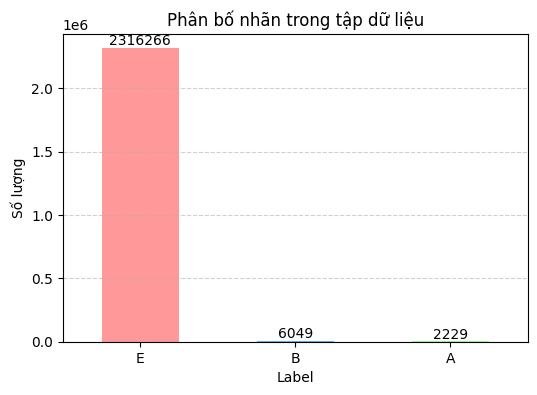

In [33]:
import matplotlib.pyplot as plt

# Tạo biểu đồ cột
plt.figure(figsize=(6,4))
label_counts = user_have_point["label_3"].value_counts()
label_counts.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'])

# Trang trí biểu đồ
plt.title('Phân bố nhãn trong tập dữ liệu')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị số lượng trên cột
for i, value in enumerate(label_counts):
    plt.text(i, value + 100, str(value), ha='center', va='bottom')

In [34]:
conditions = [
    (users_course_labeling_df["score"] >= 85) & (users_course_labeling_df["score"] <= 100),
    (users_course_labeling_df["score"] >= 70) & (users_course_labeling_df["score"] < 85),
    (users_course_labeling_df["score"] >= 60) & (users_course_labeling_df["score"] < 70),
    (users_course_labeling_df["score"] >= 30) & (users_course_labeling_df["score"] < 60),
    (users_course_labeling_df["score"] < 30)
]
labels = ["A", "B","C","D","E"]

users_course_labeling_df["label_5"] = np.select(conditions, labels, default="E")


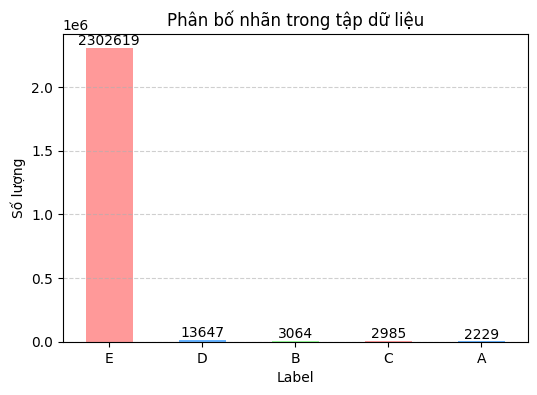

In [35]:
# Tạo biểu đồ cột
plt.figure(figsize=(6,4))
label_counts = user_have_point["label_5"].value_counts()
label_counts.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99'])

# Trang trí biểu đồ
plt.title('Phân bố nhãn trong tập dữ liệu')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị số lượng trên cột
for i, value in enumerate(label_counts):
    plt.text(i, value + 100, str(value), ha='center', va='bottom')

In [36]:
users_course_labeling_df = users_course_labeling_df.drop(columns = {'Unnamed: 0'})

In [37]:
users_course_labeling_df.isna().sum()

course_id                           0
start_date                          0
end_date                            0
assignment                          0
video                               0
exam                                0
course_duration                     0
user_id                             0
enroll_time                         0
enrollment_to_end                   0
amount_exercise_each_exam           0
total_correct_ratio_exam            0
average_correct_ratio_exam          0
amount_exercise_each_assignment     0
total_correct_ratio_assignment      0
average_correct_ratio_assignment    0
watched_videos                      0
video_counts                        0
watch_percent                       0
score                               0
label_3                             0
label_5                             0
dtype: int64

In [38]:
users_course_labeling_df.to_csv("/kaggle/working/Label_3_and_5_classes(have_course_info).csv", index=False)